## **Hepatitis C Virus (HCV) for Egyptian patients**

Group members :
Rachel SHERPA, Estelle SOBESKY, Koralie THERESINE, Yasmine ZEROUAL

**STEP 1 - Import libraries and load the dataset**

In [1]:
!pip install ucimlrepo

# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# preprocessing
from sklearn.model_selection import train_test_split, KFold, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

# evaluation
from sklearn.metrics import (accuracy_score, recall_score, confusion_matrix, classification_report, f1_score,
roc_auc_score, roc_curve)

# imbalanced data
from collections import Counter
#from imblearn.over_sampling import SMOTE, RandomOverSampler
#from imblearn.under_sampling import RandomUnderSampler

from sklearn.decomposition import PCA



## Informations on the dataset

The dataset used in this project is the Hepatitis C Virus (HCV) for Egyptian patients dataset, obtained from the UCI Machine Learning Repository.

It contains clinical, demographic and laboratory information from 1385 Egyptian patients infected with the Hepatitis C Virus (HCV).
Each record included variables such as age, BMI, blood test results, RNA measurements collected at different treatment stages.

The target variable, called Baseline Histological Staging represents the stage of liver fibrosis (F0-F3), which indicates the progression of liver damage in HCV patients.
The goal of this dataset is to enable the prediction of the fibrosis stage based on these medical features.

This topic was chosen because Hepatitis C remains a major public health issue in many countries, and using machine learning models to predict liver fibrosis can help improve early diagnosis and patient management. It has a real impact on the world.

STEP 2 - Load the dataset

In [2]:
# ML tools
from ucimlrepo import fetch_ucirepo

# Fetch dataset (UCI id = 503)
hcv = fetch_ucirepo(id=503)

# Extract features and target
X = hcv.data.features
y = hcv.data.targets

# Merge for easier exploration
df = pd.concat([X, y], axis=1)

# Quick overview
print("Shape of dataset:", df.shape)
print("Columns:", df.columns.tolist())
df.head()

Shape of dataset: (1385, 29)
Columns: ['Age ', 'Gender', 'BMI', 'Fever', 'Nausea/Vomting', 'Headache ', 'Diarrhea ', 'Fatigue & generalized bone ache ', 'Jaundice ', 'Epigastric pain ', 'WBC', 'RBC', 'HGB', 'Plat', 'AST 1', 'ALT 1', 'ALT4', 'ALT 12', 'ALT 24', 'ALT 36', 'ALT 48', 'ALT after 24 w', 'RNA Base', 'RNA 4', 'RNA 12', 'RNA EOT', 'RNA EF', 'Baseline histological Grading', 'Baselinehistological staging']


,Age,Gender,BMI,Fever,Nausea/Vomting,Headache,Diarrhea,Fatigue & generalized bone ache,Jaundice,Epigastric pain,...,ALT 36,ALT 48,ALT after 24 w,RNA Base,RNA 4,RNA 12,RNA EOT,RNA EF,Baseline histological Grading,Baselinehistological staging
0,56,1,35,2,1,1,1,2,2,2,...,5,5,5,655330,634536,288194,5,5,13,2
1,46,1,29,1,2,2,1,2,2,1,...,57,123,44,40620,538635,637056,336804,31085,4,2
2,57,1,33,2,2,2,2,1,1,1,...,5,5,5,571148,661346,5,735945,558829,4,4
3,49,2,33,1,2,1,2,1,2,1,...,48,77,33,1041941,449939,585688,744463,582301,10,3
4,59,1,32,1,1,2,1,2,2,2,...,94,90,30,660410,738756,3731527,338946,242861,11,1


**STEP 3 — Descriptive analysis of your data (EDA)**

In [3]:
# Basic info about the dataset
print("General information")
df.info()

# Descriptive statistics
print("\n Statistical summary")
display(df.describe())

# Check for missing values
print("\n Missing values per column")
missing_values = df.isna().sum()
display(missing_values[missing_values > 0])
print(df.isnull().sum())

# Check for duplicate rows
duplicates = df.duplicated().sum()
print(f"\nNumber of duplicate rows: {duplicates}")

General information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1385 entries, 0 to 1384
Data columns (total 29 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Age                               1385 non-null   int64  
 1   Gender                            1385 non-null   int64  
 2   BMI                               1385 non-null   int64  
 3   Fever                             1385 non-null   int64  
 4   Nausea/Vomting                    1385 non-null   int64  
 5   Headache                          1385 non-null   int64  
 6   Diarrhea                          1385 non-null   int64  
 7   Fatigue & generalized bone ache   1385 non-null   int64  
 8   Jaundice                          1385 non-null   int64  
 9   Epigastric pain                   1385 non-null   int64  
 10  WBC                               1385 non-null   int64  
 11  RBC                               1385 non-null  

,Age,Gender,BMI,Fever,Nausea/Vomting,Headache,Diarrhea,Fatigue & generalized bone ache,Jaundice,Epigastric pain,...,ALT 36,ALT 48,ALT after 24 w,RNA Base,RNA 4,RNA 12,RNA EOT,RNA EF,Baseline histological Grading,Baselinehistological staging
count,1385.000000,1385.000000,1385.000000,1385.000000,1385.000000,1385.000000,1385.000000,1385.000000,1385.000000,1385.000000,...,1385.000000,1385.000000,1385.000000,1.385000e+03,1.385000e+03,1.385000e+03,1385.000000,1385.000000,1385.000000,1385.000000
mean,46.319134,1.489531,28.608664,1.515523,1.502527,1.496029,1.502527,1.498917,1.501083,1.503971,...,83.117690,83.629603,33.438267,5.909512e+05,6.008956e+05,2.887536e+05,287660.336462,291378.290975,9.761733,2.536462
std,8.781506,0.500071,4.076215,0.499939,0.500174,0.500165,0.500174,0.500179,0.500179,0.500165,...,26.399031,26.223955,7.073569,3.539354e+05,3.623151e+05,2.853507e+05,264559.525070,267700.691713,4.023896,1.121392
min,32.000000,1.000000,22.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,5.000000,5.000000,5.000000,1.100000e+01,5.000000e+00,5.000000e+00,5.000000,5.000000,3.000000,1.000000
25%,39.000000,1.000000,25.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,61.000000,61.000000,28.000000,2.692530e+05,2.708930e+05,5.000000e+00,5.000000,5.000000,6.000000,2.000000
50%,46.000000,1.000000,29.000000,2.000000,2.000000,1.000000,2.000000,1.000000,2.000000,2.000000,...,84.000000,83.000000,34.000000,5.931030e+05,5.978690e+05,2.343590e+05,251376.000000,244049.000000,10.000000,3.000000
75%,54.000000,2.000000,32.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,...,106.000000,106.000000,40.000000,8.867910e+05,9.090930e+05,5.248190e+05,517806.000000,527864.000000,13.000000,4.000000
max,61.000000,2.000000,35.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,...,128.000000,128.000000,45.000000,1.201086e+06,1.201715e+06,3.731527e+06,808450.000000,810333.000000,16.000000,4.000000



 Missing values per column


Series([], dtype: int64)

Age                                 0
Gender                              0
BMI                                 0
Fever                               0
Nausea/Vomting                      0
Headache                            0
Diarrhea                            0
Fatigue & generalized bone ache     0
Jaundice                            0
Epigastric pain                     0
WBC                                 0
RBC                                 0
HGB                                 0
Plat                                0
AST 1                               0
ALT 1                               0
ALT4                                0
ALT 12                              0
ALT 24                              0
ALT 36                              0
ALT 48                              0
ALT after 24 w                      0
RNA Base                            0
RNA 4                               0
RNA 12                              0
RNA EOT                             0
RNA EF      

There are no categorical columns in this dataset. All variables are numerical (continuous or discrete clinical measurements).
Therefore, we will only apply numerical preprocessing (scaling and imputation) in the next steps no encoding is required.

## Visualization

Target column: Baselinehistological staging


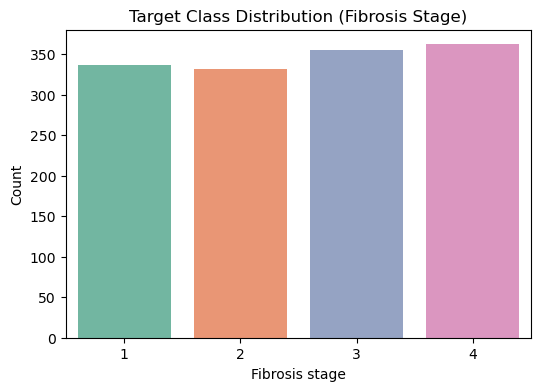


Class counts:
Baselinehistological staging
1    336
2    332
3    355
4    362
Name: count, dtype: int64

Class proportions (%):
Baselinehistological staging
1    24.26
2    23.97
3    25.63
4    26.14
Name: count, dtype: float64
Ratio (majority/minority):  1.09

Interpretation:
Low imbalance. No resampling needed


In [5]:
#  Target variable distribution

target_col = y.columns[0] if isinstance(y, pd.DataFrame) else 'target'
print("Target column:", target_col)

plt.figure(figsize=(6,4))
sns.countplot(x=y[target_col], palette='Set2')
plt.title("Target Class Distribution (Fibrosis Stage)")
plt.xlabel("Fibrosis stage")
plt.ylabel("Count")
plt.show()

# Display exact class counts
print("\nClass counts:")
class_counts= y[target_col].value_counts().sort_index()
print(class_counts)

total=class_counts.sum()
proportions=(class_counts/total *100).round(2)
print("\nClass proportions (%):")
print(proportions)

# compute ratios
max_count =class_counts.max()
min_count=class_counts.min()
ratio= round(max_count/min_count,3)
print("Ratio (majority/minority): ",ratio)

# Interpretation
print("\nInterpretation:")
if ratio <= 5:
    print("Low imbalance. No resampling needed")
elif ratio <= 20:
    print("moderate imbalance. Resampling can be considered")
elif ratio > 50:
    print("high imbalance. Resampling strongly recommended")
else:
    print("Intermediate imbalance (between 1:20 and 1:50)")

In [8]:


# Target column name
target_col = "Baselinehistological staging"

# Count samples per class
class_counts = df[target_col].value_counts().sort_index()

# Compute proportions (%)
class_proportions = (class_counts / class_counts.sum() * 100).round(2)

# Create summary table
summary_table = pd.DataFrame({
    "Count": class_counts,
    "Proportion (%)": class_proportions})

# Compute imbalance ratio (majority / minority)
ratio = round(class_counts.max() / class_counts.min(), 2)

# Display results
print("Class distribution table:")
display(summary_table)

print(f"\nImbalance ratio (majority/minority): {ratio}")


Class distribution table:


,Count,Proportion (%)
Baselinehistological staging,,
1,336,24.26
2,332,23.97
3,355,25.63
4,362,26.14



Imbalance ratio (majority/minority): 1.09



The proportions range between 23.97% and 26.14%, indicating that all classes contain a similar number of observations. Since the ratio (1.09) remains within the low imbalance interval and the class frequencies are almost identical, we conclude that the dataet is balanced and no resampling (SMOTE, oversampling, undersampling) are required.

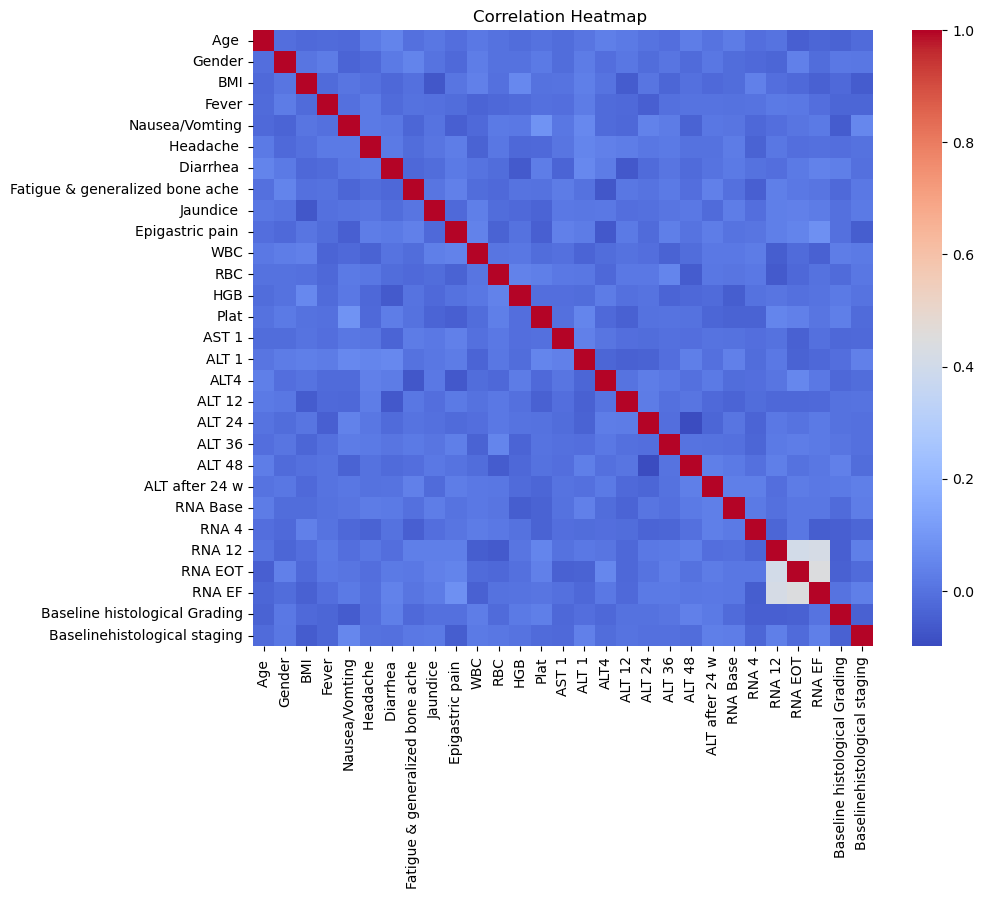

In [10]:
# Correlation heatmap

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), cmap='coolwarm', annot=False)
plt.title("Correlation Heatmap ")
plt.show()
# We only have numerical values so no need to write "numeric_only=true"


The heatmap shows that most features are only weakly correlated. The target variable shows no strong linear correlation with any feature, so non-linear models will perform better.

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


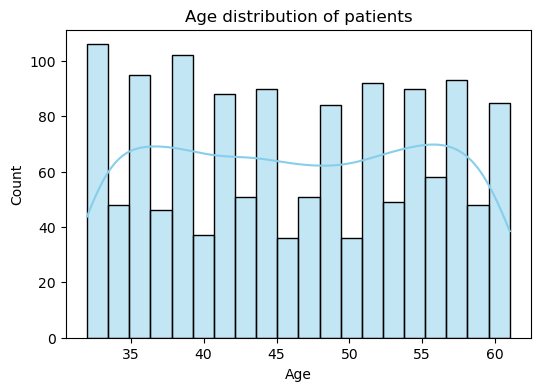

In [11]:
plt.figure(figsize=(6,4))
sns.histplot(df['Age '], bins=20, kde=True, color='skyblue')
plt.title('Age distribution of patients')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

The histogram shows the distribution of patients'ages in the dataset. Most patients are between 30 and 60 years old, with no extreme outliers. The number of patients is quite balanced across different age ranges, although there are more indivuals around 30-40 years old. This suggests that the dataset represents adult and middle-aged Egyptian patients.

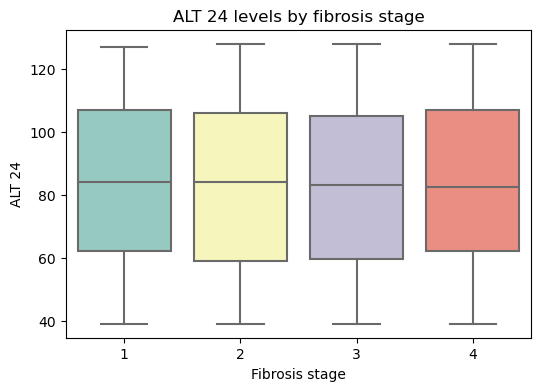

In [12]:
plt.figure(figsize=(6,4))
sns.boxplot(x='Baselinehistological staging', y='ALT 24', data=df, palette='Set3')
plt.title('ALT 24 levels by fibrosis stage')
plt.xlabel('Fibrosis stage')
plt.ylabel('ALT 24')
plt.show()


The variable ALT 24 represents the level of Alanine Aminotransferase (ALT) measured 24 weeks after treatment. ALT is an enzyme found mainly in the liver and its level increases when liver cells are damaged. Therefore, it is a key clinical indicator of liver inflammation and injury in patients with hepatitis C.

ALT 24 levels are similar across all fibrosis stages, with a slight rise in stage 4.

Some outliers appear in the ALT24 values across different fibrosis stages. However, these values are clinically plausible, as liver enzyme levels naturally vary among hepatitis C patients. Since the outliers reflect real medical variability rather than data errors, we decided to keep them in the dataset and not apply any outlier removal.

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='ALT 1', ylabel='Count'>

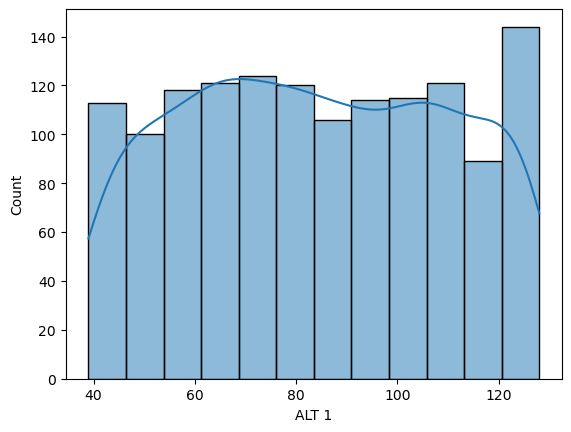

In [13]:
sns.histplot(df["ALT 1"], kde=True)

ALT 1 represents the baseline ALT enzyme level. Its distribution indicated differnt levels of liver inflammation among patients, with no extreme outliers.

In [15]:
#Check for inconsistencies
df.columns = df.columns.str.strip().str.replace(" ", "_").str.replace("/", "_").str.replace("&", "and").str.replace("__", "_")
print(df.columns.tolist())

['Age', 'Gender', 'BMI', 'Fever', 'Nausea_Vomting', 'Headache', 'Diarrhea', 'Fatigue_and_generalized_bone_ache', 'Jaundice', 'Epigastric_pain', 'WBC', 'RBC', 'HGB', 'Plat', 'AST_1', 'ALT_1', 'ALT4', 'ALT_12', 'ALT_24', 'ALT_36', 'ALT_48', 'ALT_after_24_w', 'RNA_Base', 'RNA_4', 'RNA_12', 'RNA_EOT', 'RNA_EF', 'Baseline_histological_Grading', 'Baselinehistological_staging']


**STEP 4 — Data Pre-processing**

In [16]:
# Identify categorical and numerical columns
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

print("Categorical columns:", categorical_cols)
print("Numeric columns:", numeric_cols)

Categorical columns: []
Numeric columns: ['Age', 'Gender', 'BMI', 'Fever', 'Nausea_Vomting', 'Headache', 'Diarrhea', 'Fatigue_and_generalized_bone_ache', 'Jaundice', 'Epigastric_pain', 'WBC', 'RBC', 'HGB', 'Plat', 'AST_1', 'ALT_1', 'ALT4', 'ALT_12', 'ALT_24', 'ALT_36', 'ALT_48', 'ALT_after_24_w', 'RNA_Base', 'RNA_4', 'RNA_12', 'RNA_EOT', 'RNA_EF', 'Baseline_histological_Grading', 'Baselinehistological_staging']



The dataset is a tabular numeric dataset, as all features are numerical measurements (like laboratory values, clinical indicators...). No categorical variables are present. Therefore, the preprocessing pipeline only includes numerical imputation and scaling.

Although the dataset is numeric tabular data, it does not require SMOTE or oversampling because the class distribution is well balanced (ratio = 1.09). Therefore, standard preprocessing and model training can be applied without any resampling technique.

**Handle missing values (if any)**

This preprocessing pipeline is designed to handle missing values and scale numeric features.
The SimpleImputer (with median strategy) would replace missing numeric values with the column median.
However, in this dataset there are no missing values, so the imputer will not modify the data.
We still include it for good practice and reproducibility in case new data contain NaNs.

In [17]:
# Numeric data preprocessing: imputation + scaling
numeric_transformer = Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),('scaler', StandardScaler())])

# Because we have no categorical variables, we keep only the numeric transformer
preprocessor = ColumnTransformer(transformers=[('num', numeric_transformer, numeric_cols)])

Train/Test split

In [18]:
# Extract X (features) and y (target)
X = df.drop(columns=[df.columns[-1]])  # all columns except target
y = df[df.columns[-1]] # last column = target

# Stratified split: 80% train / 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=42,stratify=y)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)


Training set shape: (1108, 28)
Test set shape: (277, 28)


**Formalization of the problem**

Formalization of the problem

The objective of this project is to predict the Baseline Histological Staging (fibrosis stage) of Egyptian patients infected with the Hepatitis C Virus (HCV) using their demographic, clinical, and laboratory data.

Each patient in the dataset is described by numerical attributes such as age, body mass index (BMI), and several blood test results (such as ALT, AST, bilirubin, platelets, albumin, etc.).

The goal is to determine the stage of liver fibrosis, a medical indicator of liver damage based on these features. This is a multiclass classification problem, since the target variable (fibrosis stage) contains several distinct categories (for example, F0, F1, F2, F3).

All predictors in the dataset are numerical, meaning that no categorical encoding is required. For the evaluation, the primary metric is the Macro F1-score, which gives equal importance to all classes and is well suited to imbalanced datasets. As secondary metrics, we will use accuracy, weighted F1-score, and a confusion matrix to visualize class-level performance. Precision–Recall curves and ROC–AUC (one-vs-rest) analyses may also be used to provide additional insights into model behavior.

The goal of this step is to build a clean and reproducible baseline model (using Logistic Regression and/or Decision Tree) in order to evaluate initial predictive performance before moving to more advanced techniques in the next steps.

In [20]:
# Define numeric columns based on X
numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()

# Numeric pipeline
numeric_transformer = Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),('scaler', StandardScaler())])

# Preprocessor
preprocessor = ColumnTransformer(transformers=[('num', numeric_transformer, numeric_cols)])


In [21]:
#Baseline models comparison
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, multi_class="multinomial"),
    "SVM (RBF)": SVC(kernel="rbf", probability=True),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42)}
results = {}

for name, model in models.items():
    clf=Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)])
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average="macro")
    recall = recall_score(y_test, y_pred, average="macro")
    print(f"\n {name} ")
    print("Accuracy:", acc)
    print("Macro f1-score:", f1)
    print("Macro recall:", recall)
    print("Classification report:\n", classification_report(y_test, y_pred))
    print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))

    results[name] = {"accuracy": acc, "f1_macro": f1,  "recall_macro": recall}



 Logistic Regression 
Accuracy: 0.24548736462093862
Macro f1-score: 0.243858379412548
Macro recall: 0.2449752411650667
Classification report:
               precision    recall  f1-score   support

           1       0.20      0.18      0.19        67
           2       0.26      0.28      0.27        67
           3       0.26      0.24      0.25        71
           4       0.25      0.28      0.26        72

    accuracy                           0.25       277
   macro avg       0.24      0.24      0.24       277
weighted avg       0.24      0.25      0.24       277

Confusion matrix:
 [[12 20 15 20]
 [16 19 17 15]
 [14 16 17 24]
 [18 17 17 20]]

 SVM (RBF) 
Accuracy: 0.26353790613718414
Macro f1-score: 0.2620424724722709
Macro recall: 0.26243416135286013
Classification report:
               precision    recall  f1-score   support

           1       0.25      0.22      0.24        67
           2       0.23      0.24      0.23        67
           3       0.29      0.27      0.2

In [22]:
import pandas as pd

# Create a comparison table
comparison_table = pd.DataFrame({
    model: {
        "Accuracy": results[model]["accuracy"],
        "F1 Macro": results[model]["f1_macro"],
        "Recall macro": results[model]["recall_macro"]}
    for model in results}).T

comparison_table = comparison_table.round(4)
comparison_table


,Accuracy,F1 Macro,Recall macro
Logistic Regression,0.2455,0.2439,0.2450
SVM (RBF),0.2635,0.2620,0.2624
Decision Tree,0.2130,0.2075,0.2108
Random Forest,0.2310,0.2284,0.2299


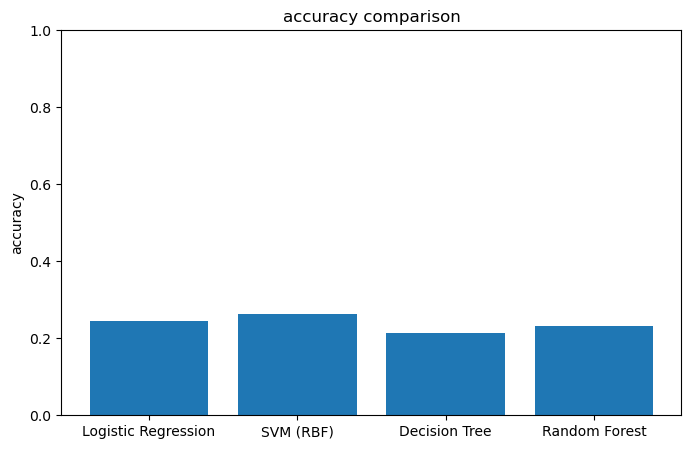

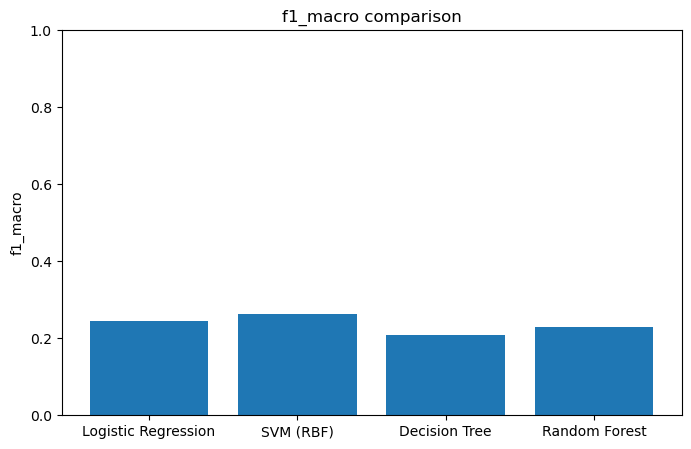

In [23]:
import matplotlib.pyplot as plt

metrics = ["accuracy", "f1_macro"]
models_names = list(results.keys())

for metric in metrics:
    values = [results[m][metric] for m in models_names]

    plt.figure(figsize=(8, 5))
    plt.bar(models_names, values)
    plt.title(f"{metric} comparison")
    plt.ylabel(metric)
    plt.ylim(0, 1)
    plt.show()


**Interpretation :**

All baseline models show low performance, with accuracies around 0.21 and 0.26 and macro f1-scores around 0.20 and 0.26. The logistic regression doesn't work well because the relationship between the variables and the fibrosis stage isn't linear. The SVM performs better, but it still confuses nearby fibrosis stages and the decision tree, it generalizes poorly. About the random forest, it gives more consistent results than a single decision tree, but its performance is still low because the model hasn't been optimized.

So, these results show that predicting fibrosis stages is a difficult task, and that more advanced models and feature optimization are needed to improve performance.

## Feature selection

Feature selection

To improve these results, the next step is to reduce the dimensionality of the dataset and identify the most informative variables. Since many features are weakly correlated with the target (heatmap), applying feature selection can help highlight the medical measurements that contribute the most to predict the fibrosis stage.

In [24]:
# filter methode : Anova (F-test)

from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import accuracy_score, f1_score

k_features = 10  #number of features to keep

anova_models = {
    "Logistic regression": LogisticRegression(
        max_iter=1000,
        multi_class="multinomial",
        random_state=42),
    "SVM (RBF)": SVC(
        kernel="rbf",
        probability=True,
        random_state=42),
    "Decision tree": DecisionTreeClassifier(
        random_state=42),
    "Random forest": RandomForestClassifier(
        random_state=42)}

anova_results_list = []

print("ANOVA F-test feature selection : models comparison")

for name, model in anova_models.items():
    anova_pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("anova", SelectKBest(score_func=f_classif, k=k_features)),
        ("model", model)])

    # fit on training set
    anova_pipeline.fit(X_train, y_train)

    # evaluate on test set
    y_pred = anova_pipeline.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average="macro")

    anova_results_list.append({
        "model": name,
        "accuracy": acc,
        "f1_macro": f1})

    print(f"\n{name}:")
    print(f"Test accuracy:{acc:.4f}")
    print(f"Test macro F1-score: {f1:.4f}")

# store results in a dataframe
anova_results_df = pd.DataFrame(anova_results_list)
display(anova_results_df)

ANOVA F-test feature selection : models comparison

Logistic regression:
Test accuracy:0.2671
Test macro F1-score: 0.2673

SVM (RBF):
Test accuracy:0.2491
Test macro F1-score: 0.2458

Decision tree:
Test accuracy:0.2527
Test macro F1-score: 0.2536

Random forest:
Test accuracy:0.2238
Test macro F1-score: 0.2190


,model,accuracy,f1_macro
0,Logistic regression,0.267148,0.267299
1,SVM (RBF),0.249097,0.245752
2,Decision tree,0.252708,0.253632
3,Random forest,0.223827,0.218974


After applying ANOVA F-test feature selection (top 10 features), logistic regression performs best, with an accuracy of 26.7% and a macro F1-score of 0.27, showing that feature selection helps reduce noise for linear models.

SVM and Decision tree show similar but slightly lower results, while random forest performs worse.

So, ANOVA improves simpler models, but performance remains low and requires further optimization.

In [26]:
# filter model : mutual information (mi)

from sklearn.feature_selection import mutual_info_classif

mi_models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        multi_class="multinomial",
        random_state=42),
    "SVM (RBF)": SVC(
        kernel="rbf",
        probability=True,
        random_state=42),
    "Decision Tree": DecisionTreeClassifier(
        random_state=42),
    "Random Forest": RandomForestClassifier(
        random_state=42)}

mi_results_list = []

print("Mutual Information feature selection : models comparison")

for name, model in mi_models.items():
    mi_pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("mi", SelectKBest(score_func=mutual_info_classif, k=k_features)),
        ("model", model)])

    # fit on training set
    mi_pipeline.fit(X_train, y_train)

    # evaluate on test set
    y_pred = mi_pipeline.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average="macro")

    mi_results_list.append({
        "model": name,
        "accuracy": acc,
        "f1_macro": f1})

    print(f"\n{name}:")
    print(f"Test accuracy: {acc:.4f}")
    print(f"Test macro F1-score: {f1:.4f}")

# store results in a sataframe
mi_results_df = pd.DataFrame(mi_results_list)
display(mi_results_df)

# Show MI Scores (top k features)

# Fit MI selector once to extract feature names
mi_selector = SelectKBest(score_func=mutual_info_classif, k=k_features)

# Apply preprocessing manually to avoid refitting pipelines
X_train_scaled = preprocessor.fit_transform(X_train)

mi_selector.fit(X_train_scaled, y_train)

mi_scores = mi_selector.scores_
mi_feature_scores = pd.DataFrame({
    "feature": X.columns,
    "MI_score": mi_scores
}).sort_values(by="MI_score", ascending=False)

print("\nTop features according to Mutual Information:")
print(mi_feature_scores.head(k_features))

Mutual Information feature selection : models comparison

Logistic Regression:
Test accuracy: 0.2563
Test macro F1-score: 0.2504

SVM (RBF):
Test accuracy: 0.2852
Test macro F1-score: 0.2818

Decision Tree:
Test accuracy: 0.2202
Test macro F1-score: 0.2185

Random Forest:
Test accuracy: 0.2708
Test macro F1-score: 0.2632


,model,accuracy,f1_macro
0,Logistic Regression,0.256318,0.250373
1,SVM (RBF),0.285199,0.281815
2,Decision Tree,0.220217,0.218471
3,Random Forest,0.270758,0.263157



Top features according to Mutual Information:
                          feature  MI_score
15                          ALT_1  0.045635
23                          RNA_4  0.043255
26                         RNA_EF  0.030416
5                        Headache  0.016488
10                            WBC  0.010551
2                             BMI  0.010496
25                        RNA_EOT  0.009707
27  Baseline_histological_Grading  0.008761
17                         ALT_12  0.004679
19                         ALT_36  0.004667



After applying mutual information feature selection (top 10 features), the SVM (RBF) model gives the best results, with an accuracy of 28.2% and a macro F1-score of 0.27. This shows that MI is effective at capturing non-linear relationships, which benefits SVM.

Logistic regression performs worse with MI, meaning that the selected features are less suited for linear models. The decision tree and random forest show similar but they still give low performance.

The most informative features according to MI are mainly RNA measurements and liver enzymes (ALT, HGB), which confirms their importance in predicting fibrosis stage.

So, mutual information slightly improves non-linear models but the performance remains low.

In [28]:
# wrapper method : forward selection

from sklearn.model_selection import cross_val_score


# model used during forward selection (Logistic regression)
wrapper_model = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        max_iter=1000,
        multi_class="multinomial",
        random_state=42))])

remaining_features = list(X_train.columns)  # features that are still available
selected_features = []
best_scores = [] # CV score at each step

print("Forward selection:")

# Loop until there are no more features to test
while len(remaining_features) > 0:
    scores_candidates = []  # store (CV score, feature) for each candidate

    # for each feature still available
    for f in remaining_features:
        features_test = selected_features + [f]

        # Compute cross-validation score using only these features
        cv_score = cross_val_score(
            wrapper_model,
            X_train[features_test],
            y_train,
            cv=5,
            scoring="f1_macro"
        ).mean()

        scores_candidates.append((cv_score, f))

    #select the feature that gives the best CV score
    best_score, best_feature = max(scores_candidates, key=lambda x: x[0])

    selected_features.append(best_feature)
    remaining_features.remove(best_feature)
    best_scores.append(best_score)

    print(f"Added feature: {best_feature:25s} | CV macro F1: {best_score:.4f}")

print("\nSelected features with forward selection:")
print(selected_features)

# Test several models on selected features

forward_models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        multi_class="multinomial",
        random_state=42),
    "SVM (RBF)": SVC(
        kernel="rbf",
        probability=True,
        random_state=42),
    "Decision Tree": DecisionTreeClassifier(
        random_state=42),
    "Random Forest": RandomForestClassifier(
        random_state=42)}

forward_results_list = []

print("\nForward selection : models comparison (using selected features)")

for name, model in forward_models.items():
    # Pipeline: scaling + model, applied only on selected features
    forward_pipeline = Pipeline(steps=[
        ("scaler", StandardScaler()),
        ("model", model)])

    # Fit on training set with selected features
    forward_pipeline.fit(X_train[selected_features], y_train)

    # evaluate on test set
    y_pred = forward_pipeline.predict(X_test[selected_features])
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average="macro")

    forward_results_list.append({
        "model": name,
        "accuracy": acc,
        "f1_macro": f1})

    print(f"\n{name}:")
    print(f"Test accuracy: {acc:.4f}")
    print(f"Test macro F1-score: {f1:.4f}")

forward_results_df = pd.DataFrame(forward_results_list)
display(forward_results_df)


Forward selection:
Added feature: RNA_EF                    | CV macro F1: 0.2466
Added feature: ALT_36                    | CV macro F1: 0.2800
Added feature: ALT_after_24_w            | CV macro F1: 0.2860
Added feature: Diarrhea                  | CV macro F1: 0.2832
Added feature: ALT_1                     | CV macro F1: 0.2902
Added feature: Age                       | CV macro F1: 0.2894
Added feature: Jaundice                  | CV macro F1: 0.3037
Added feature: RBC                       | CV macro F1: 0.2953
Added feature: Fatigue_and_generalized_bone_ache | CV macro F1: 0.2918
Added feature: ALT_48                    | CV macro F1: 0.2929
Added feature: Baseline_histological_Grading | CV macro F1: 0.2970
Added feature: RNA_12                    | CV macro F1: 0.2956
Added feature: AST_1                     | CV macro F1: 0.2885
Added feature: RNA_4                     | CV macro F1: 0.2845
Added feature: Fever                     | CV macro F1: 0.2875
Added feature: WBC      

,model,accuracy,f1_macro
0,Logistic Regression,0.245487,0.243858
1,SVM (RBF),0.263538,0.262042
2,Decision Tree,0.216606,0.215662
3,Random Forest,0.314079,0.307955


We applied forward feature selection using logistic regression and macro F1-score to progressively select the most informative features. At each step, the feature that maximized the CV macro F1-score was added to the model.

Using the selected features, the SVM (RBF) achieves the best performance, with a test accuracy of 26.4% and a macro F1-score of 0.26, showing that forward selection benefits non-linear models more than linear ones.

Logistic regression shows unsatisfactory performance, while the decision tree and random forest remain weaker, indicating that feature selection isn't sufficient to significantly improve tree-based models.

So, forward selection slightly improves model performance, but more advanced methods are still required to improve the performance.

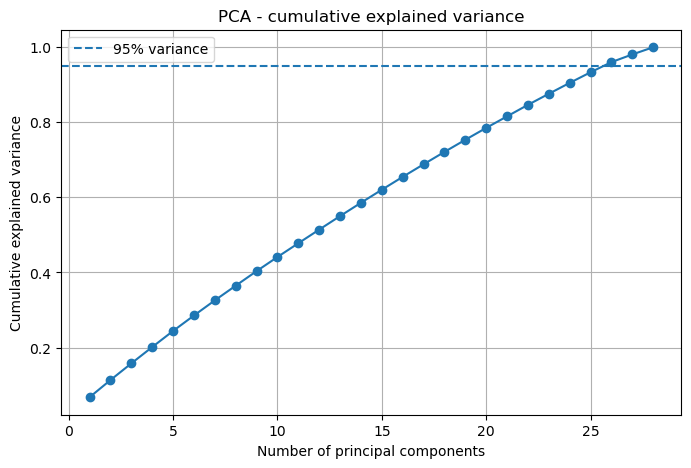

Number of components to explain 95% variance: 26


In [29]:
#PCA
from sklearn.decomposition import PCA

# Apply the preprocessing
X_train_preprocessed = preprocessor.fit_transform(X_train)

# Fit PCA on the preprocessed training data
pca_full = PCA()
pca_full.fit(X_train_preprocessed)
# Explained variance ratio
explained_var = pca_full.explained_variance_ratio_

#Cumulative explained variance
cum_explained_var = np.cumsum(explained_var)

#Plot cumulative explained variance to see how many components we need
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cum_explained_var) + 1), cum_explained_var, marker="o")
plt.axhline(0.95, linestyle="--", label="95% variance")
plt.xlabel("Number of principal components")
plt.ylabel("Cumulative explained variance")
plt.title("PCA - cumulative explained variance")
plt.legend()
plt.grid(True)
plt.show()

#choose the smallest number of components that explains at least 95% of variance
n_components_95 = np.argmax(cum_explained_var >= 0.95) + 1
print(f"Number of components to explain 95% variance: {n_components_95}")

We applied PCA on the preprocessed training data to analyze how much variance is explained by each principal component.
The cumulative explained variance curve shows that 26 principal components are required to explain 95% of the total variance.

This result shows that most of the information is spread across many features, and that PCA doesn't reduce a lot the dimensionality in this dataset.
Therefore, applying PCA is unlikely to significantly simplify the model without losing information.

In [30]:
# Build PCA pipelines and test multiple models

# models
pca_models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        multi_class="multinomial",
        random_state=42),
    "SVM (RBF)": SVC(
        kernel="rbf",
        probability=True,
        random_state=42),
    "Decision Tree": DecisionTreeClassifier(
        random_state=42),
    "Random Forest": RandomForestClassifier(
        random_state=42)}

pca_results_list = []

print("PCA and models comparison (using", n_components_95, "components):")

for name, model in pca_models.items():
    pca_pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("pca", PCA(n_components=n_components_95)),   # dimensionality reduction
        ("model", model)])

    # Fit the pipeline on the training data
    pca_pipeline.fit(X_train, y_train)

    # predict on the test set
    y_pred = pca_pipeline.predict(X_test)

    # Compute metrics
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average="macro")

    # Store results
    pca_results_list.append({
        "model": name,
        "accuracy": acc,
        "f1_macro": f1})
    print(f"\n{name}:")
    print(f"Test accuracy: {acc:.4f}")
    print(f"Test macro F1-score: {f1:.4f}")

#convert list of results to a dataframe for easy comparison
pca_results_df = pd.DataFrame(pca_results_list)
display(pca_results_df)


PCA and models comparison (using 26 components):

Logistic Regression:
Test accuracy: 0.2563
Test macro F1-score: 0.2554

SVM (RBF):
Test accuracy: 0.2455
Test macro F1-score: 0.2446

Decision Tree:
Test accuracy: 0.2744
Test macro F1-score: 0.2702

Random Forest:
Test accuracy: 0.2274
Test macro F1-score: 0.2238


,model,accuracy,f1_macro
0,Logistic Regression,0.256318,0.255362
1,SVM (RBF),0.245487,0.244592
2,Decision Tree,0.274368,0.270215
3,Random Forest,0.227437,0.223776


We tested several models using PCA with 26 components (95% variance).
Logistic regression gives the best results, with an accuracy of 25.6% and a macro F1-score of 0.26.
SVM performs slightly worse, while decision tree and random forest show lower performance.

These results show that PCA doesn't improve performance and it may remove useful information.